# Etapa 3 — Perfil, localização e fatores associados

Este notebook responde às três perguntas analíticas sobre os anúncios do Airbnb em Itapema. A métrica principal é a **mediana, entre anúncios, da diária mediana anunciada por anúncio**. Ela não representa receita realizada.

Regras permanentes desta etapa:

- amostra principal: anúncios com pelo menos 14 datas válidas;
- sensibilidades: cortes de 7 e 30 datas e diagnóstico P1–P99;
- grupos com 20+ anúncios podem ser ranqueados; 10–19 são exploratórios; menos de 10 não são ranqueáveis;
- outliers não são apagados da análise principal;
- resultados do modelo são associações, não efeitos causais;
- `data/` é somente leitura e sua integridade é verificada por SHA-256.


In [1]:
from pathlib import Path
import hashlib
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 160)
plt.style.use('seaborn-v0_8-whitegrid')


def encontrar_raiz(inicio=None):
    caminho = Path(inicio or Path.cwd()).resolve()
    for candidato in (caminho, *caminho.parents):
        if (candidato / 'data').is_dir() and (candidato / 'ROADMAP.md').is_file():
            return candidato
    raise FileNotFoundError('Raiz do projeto não encontrada.')


def sha256(caminho, tamanho_bloco=1024 * 1024):
    resumo = hashlib.sha256()
    with caminho.open('rb') as arquivo:
        for bloco in iter(lambda: arquivo.read(tamanho_bloco), b''):
            resumo.update(bloco)
    return resumo.hexdigest().upper()


def converter_booleano(serie):
    if pd.api.types.is_bool_dtype(serie.dtype):
        return serie.astype('boolean')
    mapa = {'true': True, 'false': False, '1': True, '0': False}
    return serie.astype('string').str.strip().str.lower().map(mapa).astype('boolean')


RAIZ = encontrar_raiz()
DADOS = RAIZ / 'data'
ENTRADAS_METRICAS = RAIZ / 'outputs' / 'metricas'
ENTRADAS_AUDITORIA = RAIZ / 'outputs' / 'auditoria'
SAIDAS = RAIZ / 'outputs' / 'analise'
SAIDAS.mkdir(parents=True, exist_ok=True)

HASHES_DADOS = {
    'Details_Itapema.csv': '7A28A35811B5B01CA046D06E0AF80180E43D07AF6923FC03B76DF99AC01050C9',
    'Hosts_ids_Itapema.csv': 'B2E5AA3E0BD30A3FA63643ABC4BC3142C78BE165855BBD6C4D077D6BDE308EA9',
    'Mesh_Ids_Data_Itapema.csv': '7C9DAA0D37FE5C8FA10E6EFA53CB9E6F66E28880E165A62D3E1F9C74585ADF1E',
    'Price_AV_Itapema.csv': 'B0B5C8C07011DAF5C91F2FB9E7BA735026F0AE4542745481376140A714DD813B',
    'VivaReal_Itapema.csv': 'C720320AE6BCD34982323A2D6EEC6D5F5F18E316B3A3DAE0A37F03638E32A631',
}

hashes_antes = {arquivo.name: sha256(arquivo) for arquivo in DADOS.glob('*.csv')}
assert hashes_antes == HASHES_DADOS, 'Os dados brutos diferem da versão validada.'
assert (ENTRADAS_METRICAS / 'metricas_por_anuncio.csv').is_file()
assert (ENTRADAS_AUDITORIA / 'airbnb_listings.csv').is_file()
print(f'Raiz: {RAIZ}')
print(f'Saídas permitidas: {SAIDAS}')
print('Dados brutos e entradas das Etapas 1 e 2 confirmados.')

Raiz: C:\Users\rewel\Documents\jt2026-Antonio-Rewelli-Santos
Saídas permitidas: C:\Users\rewel\Documents\jt2026-Antonio-Rewelli-Santos\outputs\analise
Dados brutos e entradas das Etapas 1 e 2 confirmados.


In [2]:
metricas = pd.read_csv(
    ENTRADAS_METRICAS / 'metricas_por_anuncio.csv',
    dtype={'airbnb_listing_id': 'string'},
    low_memory=False,
)
airbnb = pd.read_csv(
    ENTRADAS_AUDITORIA / 'airbnb_listings.csv',
    dtype={'airbnb_listing_id': 'string'},
    low_memory=False,
)

flags_metricas = [
    'is_superhost', 'is_professional', 'amostra_elegivel_7_datas',
    'amostra_elegivel_14_datas', 'amostra_elegivel_30_datas', 'amostra_preco_elegivel',
]
for coluna in flags_metricas:
    metricas[coluna] = converter_booleano(metricas[coluna]).fillna(False)

detalhes_fatores = airbnb[[
    'airbnb_listing_id', 'amenities', 'can_instant_book', 'is_guest_favorite',
    'response_rate_shown', 'response_time_shown',
]].copy()
for coluna in ['can_instant_book', 'is_guest_favorite']:
    detalhes_fatores[coluna] = converter_booleano(detalhes_fatores[coluna]).fillna(False)

base = metricas.merge(detalhes_fatores, on='airbnb_listing_id', validate='one_to_one')
assert len(base) == len(metricas) == 4441
assert base['airbnb_listing_id'].is_unique


def faixa_quartos(valor):
    if pd.isna(valor):
        return 'ausente'
    valor = int(valor)
    if valor == 0:
        return '0 (studio)'
    if valor in (1, 2, 3):
        return str(valor)
    return '4+'


def faixa_capacidade(valor):
    if pd.isna(valor):
        return 'ausente'
    valor = int(valor)
    if valor <= 2:
        return '1–2'
    if valor <= 4:
        return '3–4'
    if valor <= 6:
        return '5–6'
    return '7+'


def faixa_banheiros(valor):
    if pd.isna(valor):
        return 'ausente'
    if valor <= 1:
        return 'até 1'
    if valor <= 2:
        return '2'
    if valor <= 3:
        return '3'
    return '4+'


base['quartos_faixa'] = base['number_of_bedrooms'].map(faixa_quartos)
base['capacidade_faixa'] = base['number_of_guests'].map(faixa_capacidade)
base['banheiros_faixa'] = base['number_of_bathrooms'].map(faixa_banheiros)
base['tipo_agrupado'] = base['listing_type'].where(
    base['listing_type'].isin(['apartamento', 'casa']), 'outros'
)
base['perfil_combinado'] = (
    base['tipo_agrupado'] + ' | ' + base['quartos_faixa'] + ' quarto(s) | '
    + base['capacidade_faixa'] + ' hóspede(s)'
)

texto_comodidades = base['amenities'].fillna('').astype('string').str.lower()
padroes_comodidades = {
    'comodidade_piscina': ['piscina'],
    'comodidade_elevador': ['elevador'],
    'comodidade_churrasqueira': ['churrasqueira'],
    'comodidade_vista_praia': ['vista para a praia', 'vista para o mar', 'vista para o oceano'],
    'comodidade_estacionamento': ['estacionamento'],
    'comodidade_ar_condicionado': ['ar-condicionado', 'ar condicionado'],
    'comodidade_wifi': ['wi-fi', 'wifi'],
}
for coluna, padroes in padroes_comodidades.items():
    mascara = pd.Series(False, index=base.index)
    for padrao in padroes:
        mascara |= texto_comodidades.str.contains(padrao, regex=False, na=False)
    base[coluna] = mascara

elegiveis = base.loc[base['amostra_elegivel_14_datas']].copy()
limite_p1, limite_p99 = elegiveis['diaria_mediana_anunciada'].quantile([0.01, 0.99])
elegiveis['fora_p1_p99'] = ~elegiveis['diaria_mediana_anunciada'].between(limite_p1, limite_p99)

coordenadas_validas = (
    elegiveis['latitude_analitica'].between(-90, 90)
    & elegiveis['longitude_analitica'].between(-180, 180)
    & elegiveis['latitude_analitica'].ne(0)
    & elegiveis['longitude_analitica'].ne(0)
)
assert coordenadas_validas.all(), 'Há coordenadas analíticas inválidas na amostra principal.'

resumo_universo = pd.DataFrame([{
    'anuncios_totais': len(base),
    'elegiveis_7_datas': int(base['amostra_elegivel_7_datas'].sum()),
    'elegiveis_14_datas': int(base['amostra_elegivel_14_datas'].sum()),
    'elegiveis_30_datas': int(base['amostra_elegivel_30_datas'].sum()),
    'limite_p1_reais': limite_p1,
    'limite_p99_reais': limite_p99,
    'coordenadas_validas_elegiveis': int(coordenadas_validas.sum()),
    'taxa_resposta_nao_nula': int(elegiveis['response_rate_shown'].notna().sum()),
}])
display(resumo_universo)

,anuncios_totais,elegiveis_7_datas,elegiveis_14_datas,elegiveis_30_datas,limite_p1_reais,limite_p99_reais,coordenadas_validas_elegiveis,taxa_resposta_nao_nula
0,4441,991,959,859,152.9,2271.0,959,0


In [3]:
OCUPACAO_BASE = 0.55
DIAS_ANO = 365
MINIMO_RANKING = 20
MINIMO_EXPLORATORIO = 10
PERIODO = '2025-01-07 a 2025-04-20'
FONTE = 'Airbnb, preços anunciados; capturas de 2025-01-06 a 2025-01-20'


def status_amostra(n):
    if n >= MINIMO_RANKING:
        return 'ranqueavel'
    if n >= MINIMO_EXPLORATORIO:
        return 'exploratorio'
    return 'nao_ranqueavel'


def resumir_segmentos(df, coluna, dimensao, flag='amostra_elegivel_14_datas', filtro_extremos=False):
    trabalho = df.copy()
    trabalho['categoria'] = trabalho[coluna].astype('string').fillna('ausente')
    totais = trabalho.groupby('categoria', dropna=False).agg(
        anuncios_totais=('airbnb_listing_id', 'size'),
    )
    amostra = trabalho.loc[trabalho[flag]].copy()
    if filtro_extremos:
        p1, p99 = amostra['diaria_mediana_anunciada'].quantile([0.01, 0.99])
        amostra = amostra.loc[amostra['diaria_mediana_anunciada'].between(p1, p99)].copy()
    amostra['categoria'] = amostra[coluna].astype('string').fillna('ausente')
    amostra['premio_fim_semana_percentual'] = np.where(
        amostra['diaria_mediana_dia_util'].gt(0) & amostra['diaria_mediana_fim_semana'].notna(),
        (amostra['diaria_mediana_fim_semana'] / amostra['diaria_mediana_dia_util'] - 1) * 100,
        np.nan,
    )
    resumo = amostra.groupby('categoria', dropna=False).agg(
        anuncios_elegiveis=('airbnb_listing_id', 'size'),
        diaria_mediana_anunciada=('diaria_mediana_anunciada', 'median'),
        diaria_p25_anunciada=('diaria_mediana_anunciada', lambda s: s.quantile(0.25)),
        diaria_p75_anunciada=('diaria_mediana_anunciada', lambda s: s.quantile(0.75)),
        premio_fim_semana_mediano_percentual=('premio_fim_semana_percentual', 'median'),
    )
    resultado = totais.join(resumo, how='left').reset_index()
    resultado.insert(0, 'dimensao', dimensao)
    resultado['anuncios_elegiveis'] = resultado['anuncios_elegiveis'].fillna(0).astype(int)
    resultado['cobertura_elegivel_percentual'] = (
        resultado['anuncios_elegiveis'] / resultado['anuncios_totais'] * 100
    )
    resultado['potencial_bruto_anualizado_base'] = (
        resultado['diaria_mediana_anunciada'] * DIAS_ANO * OCUPACAO_BASE
    )
    resultado['status_amostra'] = resultado['anuncios_elegiveis'].map(status_amostra)
    resultado['ranking'] = pd.NA
    mascara_ranking = resultado['status_amostra'].eq('ranqueavel')
    resultado.loc[mascara_ranking, 'ranking'] = (
        resultado.loc[mascara_ranking, 'diaria_mediana_anunciada']
        .rank(method='min', ascending=False).astype('Int64')
    )
    resultado['periodo_estadias'] = PERIODO
    resultado['unidade_diaria'] = 'R$ por noite anunciada'
    resultado['fonte'] = FONTE
    resultado['_ordem_status'] = resultado['status_amostra'].map(
        {'ranqueavel': 0, 'exploratorio': 1, 'nao_ranqueavel': 2}
    )
    return resultado.sort_values(
        ['_ordem_status', 'diaria_mediana_anunciada'], ascending=[True, False], na_position='last'
    ).drop(columns='_ordem_status').reset_index(drop=True)


dimensoes_perfil = [
    ('tipo_agrupado', 'tipo_anuncio'),
    ('quartos_faixa', 'numero_quartos'),
    ('capacidade_faixa', 'capacidade_hospedes'),
    ('perfil_combinado', 'perfil_combinado'),
]
perfil_segmentos = pd.concat(
    [resumir_segmentos(base, coluna, dimensao) for coluna, dimensao in dimensoes_perfil],
    ignore_index=True,
)

sensibilidades = []
for limite in [7, 14, 30]:
    flag = f'amostra_elegivel_{limite}_datas'
    for coluna, dimensao in dimensoes_perfil + [('suburb_key', 'bairro')]:
        parcial = resumir_segmentos(base, coluna, dimensao, flag=flag)
        parcial['corte_datas'] = limite
        parcial['tratamento_extremos'] = 'amostra_completa'
        sensibilidades.append(parcial)

for coluna, dimensao in dimensoes_perfil + [('suburb_key', 'bairro')]:
    parcial = resumir_segmentos(
        base, coluna, dimensao, flag='amostra_elegivel_14_datas', filtro_extremos=True
    )
    parcial['corte_datas'] = 14
    parcial['tratamento_extremos'] = 'diagnostico_p1_p99'
    sensibilidades.append(parcial)

sensibilidade_resultados = pd.concat(sensibilidades, ignore_index=True)

display(Markdown('## Comparação de perfis'))
display(perfil_segmentos.loc[
    perfil_segmentos['status_amostra'].eq('ranqueavel'),
    ['dimensao', 'categoria', 'anuncios_elegiveis', 'diaria_mediana_anunciada',
     'diaria_p25_anunciada', 'diaria_p75_anunciada', 'ranking'],
].sort_values(['dimensao', 'ranking']).head(30))

## Comparação de perfis

,dimensao,categoria,anuncios_elegiveis,diaria_mediana_anunciada,diaria_p25_anunciada,diaria_p75_anunciada,ranking
8,capacidade_hospedes,7+,397,700.00000,500.00,937.3333,1
9,capacidade_hospedes,5–6,372,520.50000,394.50,680.0000,2
10,capacidade_hospedes,3–4,127,479.00000,350.00,557.0000,3
11,capacidade_hospedes,1–2,63,372.00000,196.50,427.0000,4
3,numero_quartos,4+,89,1080.00000,849.50,1657.0000,1
4,numero_quartos,3,385,650.00000,500.00,822.0000,2
5,numero_quartos,2,340,450.00000,350.00,590.0000,3
6,numero_quartos,1,137,390.00000,311.00,509.0000,4
12,perfil_combinado,apartamento | 4+ quarto(s) | 7+ hóspede(s),70,987.50000,800.00,1596.5000,1
13,perfil_combinado,apartamento | 3 quarto(s) | 5–6 hóspede(s),114,659.62500,500.00,817.7500,2


In [4]:
localizacao_segmentos = resumir_segmentos(base, 'suburb_key', 'bairro')
nomes_bairros = (
    base.dropna(subset=['suburb_key', 'suburb'])
    .groupby('suburb_key')['suburb']
    .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0])
    .to_dict()
)
localizacao_segmentos['bairro'] = localizacao_segmentos['categoria'].map(nomes_bairros).fillna(
    localizacao_segmentos['categoria']
)

bairros_ranqueaveis = localizacao_segmentos.loc[
    localizacao_segmentos['status_amostra'].eq('ranqueavel'), 'categoria'
].tolist()

# Padronização direta: apartamentos de 2 e 3 quartos são os estratos comuns
# com pelo menos 10 observações em cada bairro ranqueável.
controle = elegiveis.loc[
    elegiveis['suburb_key'].isin(bairros_ranqueaveis)
    & elegiveis['listing_type'].eq('apartamento')
    & elegiveis['number_of_bedrooms'].isin([1, 2, 3])
].copy()
contagens_celulas = controle.groupby(['suburb_key', 'number_of_bedrooms']).size().unstack(fill_value=0)
estratos_comuns = [
    int(quartos) for quartos in contagens_celulas.columns
    if contagens_celulas[quartos].ge(MINIMO_EXPLORATORIO).all()
]
assert estratos_comuns, 'Não há estratos comuns suficientes para comparação controlada.'
estratos_texto = ' e '.join(map(str, estratos_comuns))

controle = controle.loc[controle['number_of_bedrooms'].isin(estratos_comuns)].copy()
pesos_estratos = controle['number_of_bedrooms'].value_counts(normalize=True).sort_index()
celulas = controle.groupby(['suburb_key', 'number_of_bedrooms']).agg(
    anuncios_celula=('airbnb_listing_id', 'size'),
    diaria_mediana_celula=('diaria_mediana_anunciada', 'median'),
).reset_index()
celulas['peso_referencia'] = celulas['number_of_bedrooms'].map(pesos_estratos)
celulas['parcela_padronizada'] = celulas['diaria_mediana_celula'] * celulas['peso_referencia']

controlado = celulas.groupby('suburb_key').agg(
    anuncios_comparacao_controlada=('anuncios_celula', 'sum'),
    diaria_padronizada_apartamentos=('parcela_padronizada', 'sum'),
).reset_index()
controlado['estratos_comuns_quartos'] = ', '.join(map(str, estratos_comuns))
controlado['potencial_bruto_anualizado_base_controlado'] = (
    controlado['diaria_padronizada_apartamentos'] * DIAS_ANO * OCUPACAO_BASE
)

localizacao_segmentos = localizacao_segmentos.merge(
    controlado, left_on='categoria', right_on='suburb_key', how='left', validate='one_to_one'
).drop(columns='suburb_key')
localizacao_segmentos['ranking_controlado'] = pd.NA
mascara_controlada = localizacao_segmentos['diaria_padronizada_apartamentos'].notna()
localizacao_segmentos.loc[mascara_controlada, 'ranking_controlado'] = (
    localizacao_segmentos.loc[mascara_controlada, 'diaria_padronizada_apartamentos']
    .rank(method='min', ascending=False).astype('Int64')
)

display(Markdown('## Comparação de localização'))
display(localizacao_segmentos.loc[
    localizacao_segmentos['status_amostra'].eq('ranqueavel'),
    ['bairro', 'anuncios_elegiveis', 'diaria_mediana_anunciada', 'ranking',
     'diaria_padronizada_apartamentos', 'estratos_comuns_quartos', 'ranking_controlado'],
].sort_values('ranking_controlado'))

## Comparação de localização

,bairro,anuncios_elegiveis,diaria_mediana_anunciada,ranking,diaria_padronizada_apartamentos,estratos_comuns_quartos,ranking_controlado
1,Centro,200,508.75,2,669.027314,"2, 3",1
0,Meia Praia,607,589.00,1,560.773900,"2, 3",2
2,Morretes,77,470.00,3,542.788185,"2, 3",3


In [5]:
ROTULOS_MODELO = {
    'reviews_log2': 'Dobro em (reviews + 1)',
    'avaliacao_centrada': '+1 ponto na avaliação (entre avaliados)',
    'possui_avaliacao': 'Possui avaliação',
    'taxa_limpeza_100': '+R$ 100 na taxa de limpeza',
    'is_superhost': 'Superhost',
    'is_professional': 'Anfitrião profissional',
    'can_instant_book': 'Reserva instantânea',
    'is_guest_favorite': 'Preferido dos hóspedes',
    'comodidade_piscina': 'Com piscina',
    'comodidade_elevador': 'Com elevador',
    'comodidade_churrasqueira': 'Com churrasqueira',
    'comodidade_vista_praia': 'Com menção a vista para praia/mar',
    'comodidade_estacionamento': 'Com estacionamento',
}


def preparar_modelo(df):
    trabalho = df.copy()
    trabalho['bairro_modelo'] = trabalho['suburb_key'].where(
        trabalho['suburb_key'].isin(bairros_ranqueaveis), 'outros_bairros'
    )
    trabalho['avaliado'] = trabalho['number_of_reviews'].gt(0) & trabalho['star_rating'].gt(0)
    mediana_avaliacao = trabalho.loc[trabalho['avaliado'], 'star_rating'].median()
    trabalho['avaliacao_centrada'] = np.where(
        trabalho['avaliado'], trabalho['star_rating'] - mediana_avaliacao, 0
    )
    trabalho['possui_avaliacao'] = trabalho['avaliado'].astype(float)
    trabalho['reviews_log2'] = np.log2(trabalho['number_of_reviews'].clip(lower=0) + 1)
    trabalho['taxa_limpeza_100'] = trabalho['cleaning_fee'] / 100

    numericas = [
        'reviews_log2', 'avaliacao_centrada', 'possui_avaliacao', 'taxa_limpeza_100',
        'is_superhost', 'is_professional', 'can_instant_book', 'is_guest_favorite',
        'comodidade_piscina', 'comodidade_elevador', 'comodidade_churrasqueira',
        'comodidade_vista_praia', 'comodidade_estacionamento',
    ]
    x = trabalho[numericas].astype(float).copy()

    categoricas = {
        'quartos_faixa': '2',
        'capacidade_faixa': '5–6',
        'banheiros_faixa': '2',
        'tipo_agrupado': 'apartamento',
        'bairro_modelo': 'meiapraia',
    }
    referencias = []
    for coluna, referencia in categoricas.items():
        dummies = pd.get_dummies(trabalho[coluna], prefix=coluna, dtype=float)
        coluna_referencia = f'{coluna}_{referencia}'
        assert coluna_referencia in dummies.columns, f'Referência ausente: {coluna_referencia}'
        dummies = dummies.drop(columns=coluna_referencia)
        x = pd.concat([x, dummies], axis=1)
        referencias.append(f'{coluna}={referencia}')

    # Remove variáveis sem variação para evitar colunas não identificáveis.
    x = x.loc[:, x.nunique(dropna=False).gt(1)]
    x.insert(0, 'intercepto', 1.0)
    y = np.log(trabalho['diaria_mediana_anunciada'].astype(float))
    return trabalho, x.astype(float), y.astype(float), referencias


def ajustar_ols_hc3(df, cenario):
    trabalho, x_df, y_serie, referencias = preparar_modelo(df)
    x = x_df.to_numpy(dtype=float)
    y = y_serie.to_numpy(dtype=float)
    xtx_inv = np.linalg.pinv(x.T @ x)
    beta = xtx_inv @ x.T @ y
    residuos = y - x @ beta
    alavancagem = np.einsum('ij,jk,ik->i', x, xtx_inv, x)
    ajuste_hc3 = (residuos / np.clip(1 - alavancagem, 1e-8, None)) ** 2
    meat = x.T @ (x * ajuste_hc3[:, None])
    cov_hc3 = xtx_inv @ meat @ xtx_inv
    erro_padrao = np.sqrt(np.clip(np.diag(cov_hc3), 0, None))
    r2 = 1 - np.sum(residuos ** 2) / np.sum((y - y.mean()) ** 2)

    resultado = pd.DataFrame({
        'variavel': x_df.columns,
        'coeficiente_log': beta,
        'erro_padrao_hc3': erro_padrao,
    })
    resultado['limite_inferior_log_95'] = resultado['coeficiente_log'] - 1.96 * resultado['erro_padrao_hc3']
    resultado['limite_superior_log_95'] = resultado['coeficiente_log'] + 1.96 * resultado['erro_padrao_hc3']
    for origem, destino in [
        ('coeficiente_log', 'associacao_percentual_aproximada'),
        ('limite_inferior_log_95', 'limite_inferior_percentual_95'),
        ('limite_superior_log_95', 'limite_superior_percentual_95'),
    ]:
        resultado[destino] = np.expm1(resultado[origem].clip(-10, 10)) * 100
    resultado['rotulo'] = resultado['variavel'].map(ROTULOS_MODELO).fillna(
        resultado['variavel'].str.replace('_', ' ', regex=False)
    )
    resultado['cenario_modelo'] = cenario
    resultado['anuncios_modelo'] = len(trabalho)
    resultado['r_quadrado'] = r2
    resultado['referencias_categoricas'] = '; '.join(referencias)
    resultado['interpretacao'] = 'associacao_condicional_nao_causal'
    return resultado


modelos = []
for limite in [7, 14, 30]:
    amostra_modelo = base.loc[base[f'amostra_elegivel_{limite}_datas']].copy()
    modelos.append(ajustar_ols_hc3(amostra_modelo, f'corte_{limite}_datas'))

amostra_sem_extremos = elegiveis.loc[
    elegiveis['diaria_mediana_anunciada'].between(limite_p1, limite_p99)
].copy()
modelos.append(ajustar_ols_hc3(amostra_sem_extremos, 'corte_14_datas_diagnostico_p1_p99'))
fatores_associados = pd.concat(modelos, ignore_index=True)

modelo_principal = fatores_associados.loc[
    fatores_associados['cenario_modelo'].eq('corte_14_datas')
    & fatores_associados['variavel'].ne('intercepto')
].copy()
modelo_principal['intervalo_exclui_zero'] = (
    modelo_principal['limite_inferior_percentual_95'].gt(0)
    | modelo_principal['limite_superior_percentual_95'].lt(0)
)

display(Markdown('## Fatores associados à diária anunciada'))
display(modelo_principal.sort_values('associacao_percentual_aproximada', ascending=False)[[
    'rotulo', 'associacao_percentual_aproximada', 'limite_inferior_percentual_95',
    'limite_superior_percentual_95', 'intervalo_exclui_zero',
]].head(15))

## Fatores associados à diária anunciada

,rotulo,associacao_percentual_aproximada,limite_inferior_percentual_95,limite_superior_percentual_95,intervalo_exclui_zero
46,quartos faixa 4+,70.299413,49.568826,93.903308,True
31,+1 ponto na avaliação (entre avaliados),46.553898,21.301127,77.063855,True
51,banheiros faixa 4+,44.324059,27.931061,62.817643,True
45,quartos faixa 3,23.196219,14.367705,32.706242,True
38,Com piscina,22.069427,10.526286,34.818110,True
50,banheiros faixa 3,22.067795,13.939991,30.775388,True
35,Anfitrião profissional,18.303369,9.672211,27.613795,True
41,Com menção a vista para praia/mar,15.649245,9.857940,21.745845,True
40,Com churrasqueira,5.783709,-0.074307,11.985144,False
42,Com estacionamento,5.133483,-3.505621,14.546042,False


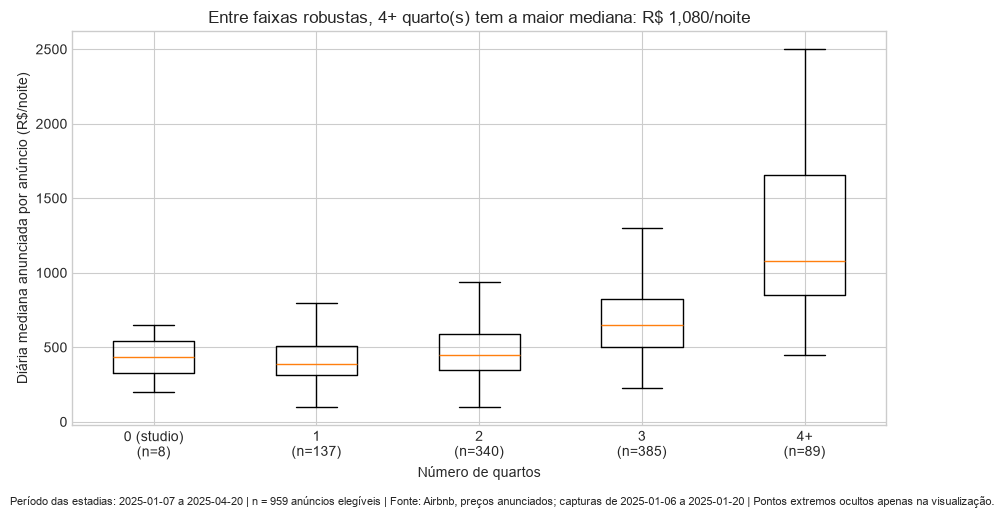

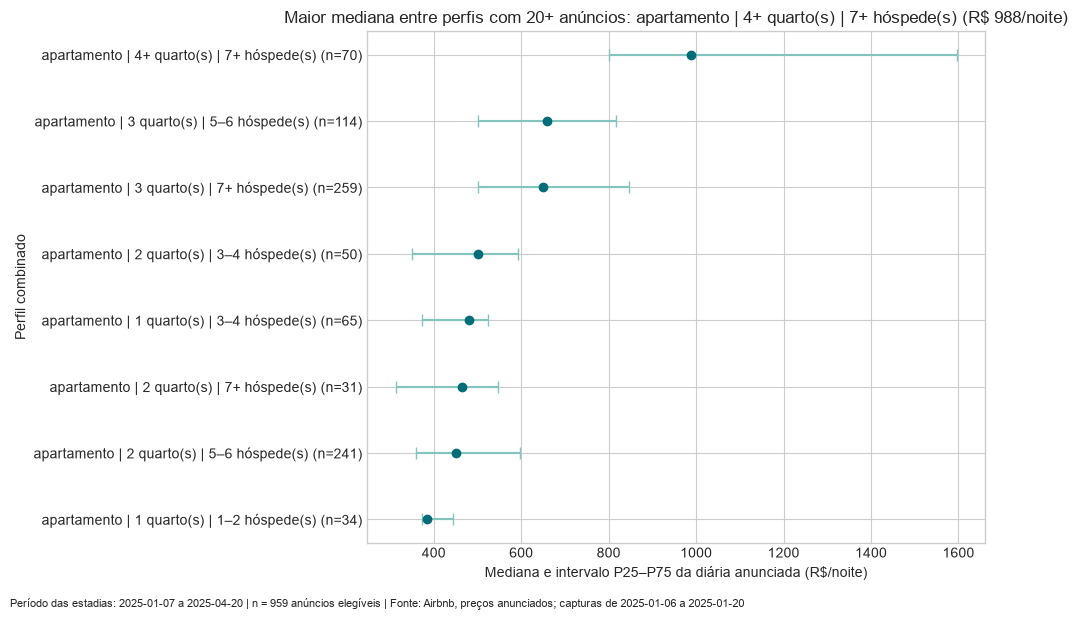

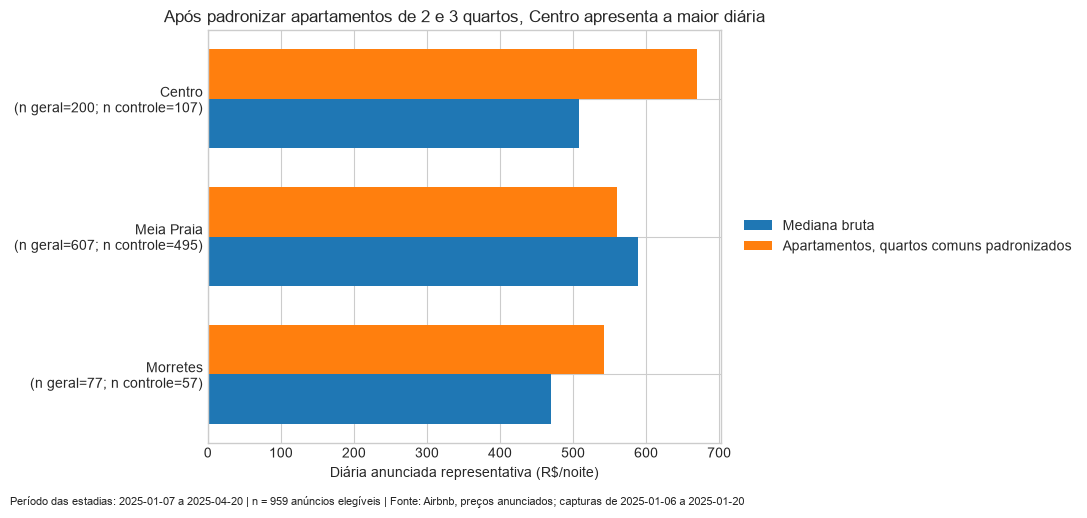

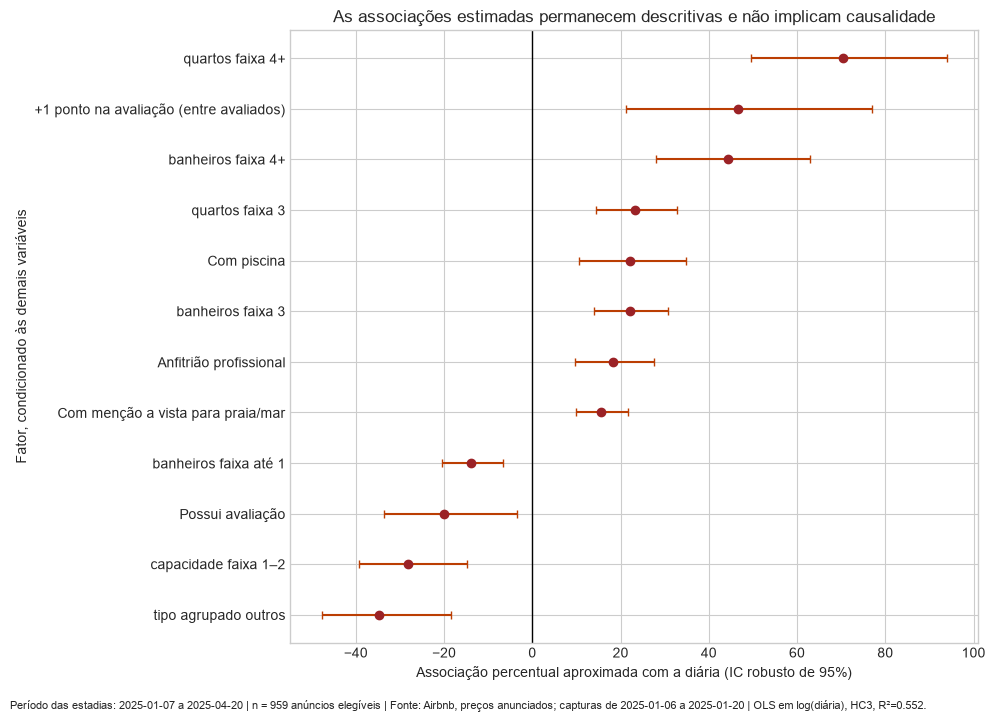

In [6]:
def caminho_saida(nome):
    destino = (SAIDAS / nome).resolve()
    assert destino.parent == SAIDAS.resolve(), f'Saída fora do diretório permitido: {destino}'
    return destino


def salvar_figura(nome):
    plt.tight_layout()
    plt.savefig(caminho_saida(nome), dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()


rodape = f'Período das estadias: {PERIODO} | n = {len(elegiveis)} anúncios elegíveis | Fonte: {FONTE}'

# 1. Distribuição por quartos (outliers preservados nos cálculos, ocultos apenas na caixa visual).
ordem_quartos = ['0 (studio)', '1', '2', '3', '4+']
dados_box = [
    elegiveis.loc[elegiveis['quartos_faixa'].eq(c), 'diaria_mediana_anunciada'].dropna()
    for c in ordem_quartos
]
resumo_quartos = perfil_segmentos.loc[
    perfil_segmentos['dimensao'].eq('numero_quartos')
    & perfil_segmentos['status_amostra'].eq('ranqueavel')
].sort_values('ranking')
lider_quartos = resumo_quartos.iloc[0]
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(dados_box, tick_labels=[f'{c}\n(n={len(d)})' for c, d in zip(ordem_quartos, dados_box)], showfliers=False)
ax.set_title(
    f"Entre faixas robustas, {lider_quartos['categoria']} quarto(s) tem a maior mediana: "
    f"R$ {lider_quartos['diaria_mediana_anunciada']:,.0f}/noite"
)
ax.set_xlabel('Número de quartos')
ax.set_ylabel('Diária mediana anunciada por anúncio (R$/noite)')
fig.text(0.01, -0.02, rodape + ' | Pontos extremos ocultos apenas na visualização.', fontsize=8)
salvar_figura('01_diaria_por_quartos.png')

# 2. Perfis combinados ranqueáveis.
perfis_plot = perfil_segmentos.loc[
    perfil_segmentos['dimensao'].eq('perfil_combinado')
    & perfil_segmentos['status_amostra'].eq('ranqueavel')
].sort_values('diaria_mediana_anunciada').tail(8)
lider_perfil = perfis_plot.sort_values('diaria_mediana_anunciada', ascending=False).iloc[0]
perfis_plot['rotulo_plot'] = perfis_plot.apply(
    lambda linha: f"{linha['categoria']} (n={int(linha['anuncios_elegiveis'])})", axis=1
)
fig, ax = plt.subplots(figsize=(10, 6))
xerr = np.vstack([
    perfis_plot['diaria_mediana_anunciada'] - perfis_plot['diaria_p25_anunciada'],
    perfis_plot['diaria_p75_anunciada'] - perfis_plot['diaria_mediana_anunciada'],
])
ax.errorbar(
    perfis_plot['diaria_mediana_anunciada'], perfis_plot['rotulo_plot'], xerr=xerr,
    fmt='o', capsize=4, color='#006d77', ecolor='#83c5be'
)
ax.set_title(
    f"Maior mediana entre perfis com 20+ anúncios: {lider_perfil['categoria']} "
    f"(R$ {lider_perfil['diaria_mediana_anunciada']:,.0f}/noite)"
)
ax.set_xlabel('Mediana e intervalo P25–P75 da diária anunciada (R$/noite)')
ax.set_ylabel('Perfil combinado')
fig.text(0.01, -0.02, rodape, fontsize=8)
salvar_figura('02_perfis_comparaveis.png')

# 3. Bairro bruto versus comparação padronizada.
loc_plot = localizacao_segmentos.loc[mascara_controlada].sort_values('diaria_padronizada_apartamentos').copy()
loc_plot['rotulo_plot'] = loc_plot.apply(
    lambda linha: f"{linha['bairro']}\n(n geral={int(linha['anuncios_elegiveis'])}; n controle={int(linha['anuncios_comparacao_controlada'])})",
    axis=1,
)
posicoes = np.arange(len(loc_plot))
largura = 0.36
lider_controlado = loc_plot.sort_values('diaria_padronizada_apartamentos', ascending=False).iloc[0]
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(posicoes - largura / 2, loc_plot['diaria_mediana_anunciada'], largura, label='Mediana bruta')
ax.barh(posicoes + largura / 2, loc_plot['diaria_padronizada_apartamentos'], largura, label='Apartamentos, quartos comuns padronizados')
ax.set_yticks(posicoes, loc_plot['rotulo_plot'])
ax.set_xlabel('Diária anunciada representativa (R$/noite)')
ax.set_title(
    f"Após padronizar apartamentos de {estratos_texto} quartos, "
    f"{lider_controlado['bairro']} apresenta a maior diária"
)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.text(0.01, -0.02, rodape, fontsize=8)
salvar_figura('03_bairros_bruto_controlado.png')

# 4. Associações do modelo principal.
fatores_plot = modelo_principal.loc[
    modelo_principal['intervalo_exclui_zero']
].copy()
if len(fatores_plot) < 6:
    fatores_plot = modelo_principal.copy()
fatores_plot['magnitude'] = fatores_plot['associacao_percentual_aproximada'].abs()
fatores_plot = fatores_plot.nlargest(12, 'magnitude').sort_values('associacao_percentual_aproximada')
fig, ax = plt.subplots(figsize=(10, 7))
x = fatores_plot['associacao_percentual_aproximada']
xerr = np.vstack([
    x - fatores_plot['limite_inferior_percentual_95'],
    fatores_plot['limite_superior_percentual_95'] - x,
])
ax.errorbar(x, fatores_plot['rotulo'], xerr=xerr, fmt='o', capsize=3, color='#9b2226', ecolor='#bb3e03')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Associação percentual aproximada com a diária (IC robusto de 95%)')
ax.set_ylabel('Fator, condicionado às demais variáveis')
ax.set_title('As associações estimadas permanecem descritivas e não implicam causalidade')
fig.text(
    0.01, -0.02,
    rodape + f" | OLS em log(diária), HC3, R²={modelo_principal['r_quadrado'].iloc[0]:.3f}.",
    fontsize=8,
)
salvar_figura('04_fatores_associados.png')

In [7]:
perfil_segmentos.to_csv(caminho_saida('perfil_segmentos.csv'), index=False, encoding='utf-8')
localizacao_segmentos.to_csv(caminho_saida('localizacao_segmentos.csv'), index=False, encoding='utf-8')
fatores_associados.to_csv(caminho_saida('fatores_associados.csv'), index=False, encoding='utf-8')
sensibilidade_resultados.to_csv(caminho_saida('sensibilidade_resultados.csv'), index=False, encoding='utf-8')


def lider_sensibilidade(dimensao, tratamento='amostra_completa', corte=14):
    candidatos = sensibilidade_resultados.loc[
        sensibilidade_resultados['dimensao'].eq(dimensao)
        & sensibilidade_resultados['tratamento_extremos'].eq(tratamento)
        & sensibilidade_resultados['corte_datas'].eq(corte)
        & sensibilidade_resultados['status_amostra'].eq('ranqueavel')
    ].sort_values('ranking')
    return candidatos.iloc[0] if len(candidatos) else None


lideres_sensibilidade = {
    (dimensao, corte, tratamento): lider_sensibilidade(dimensao, tratamento, corte)
    for dimensao in ['tipo_anuncio', 'numero_quartos', 'capacidade_hospedes', 'perfil_combinado', 'bairro']
    for corte, tratamento in [(7, 'amostra_completa'), (14, 'amostra_completa'),
                              (30, 'amostra_completa'), (14, 'diagnostico_p1_p99')]
}

linhas_estabilidade = []
for dimensao in ['tipo_anuncio', 'numero_quartos', 'capacidade_hospedes', 'perfil_combinado', 'bairro']:
    lideres = [
        lideres_sensibilidade[(dimensao, 7, 'amostra_completa')]['categoria'],
        lideres_sensibilidade[(dimensao, 14, 'amostra_completa')]['categoria'],
        lideres_sensibilidade[(dimensao, 30, 'amostra_completa')]['categoria'],
        lideres_sensibilidade[(dimensao, 14, 'diagnostico_p1_p99')]['categoria'],
    ]
    linhas_estabilidade.append(
        f"- **{dimensao}:** líderes 7/14/30 datas e P1–P99 = "
        + ' / '.join(map(str, lideres))
        + (" — estável." if len(set(lideres)) == 1 else " — sensível ao corte; interpretar com cautela.")
    )

lider_perfil_geral = perfil_segmentos.loc[
    perfil_segmentos['dimensao'].eq('perfil_combinado')
    & perfil_segmentos['status_amostra'].eq('ranqueavel')
].sort_values('ranking').iloc[0]
lider_bairro_bruto = localizacao_segmentos.loc[
    localizacao_segmentos['status_amostra'].eq('ranqueavel')
].sort_values('ranking').iloc[0]
lider_bairro_controlado = localizacao_segmentos.loc[
    localizacao_segmentos['ranking_controlado'].notna()
].sort_values('ranking_controlado').iloc[0]

fatores_com_intervalo = modelo_principal.loc[modelo_principal['intervalo_exclui_zero']].copy()
fator_positivo = fatores_com_intervalo.sort_values('associacao_percentual_aproximada', ascending=False).iloc[0]
fator_negativo = fatores_com_intervalo.sort_values('associacao_percentual_aproximada').iloc[0]

resumo = f'''# Resultados da Etapa 3 — Airbnb em Itapema

## Escopo e métrica

- Universo: {len(base):,} anúncios; amostra principal: {len(elegiveis):,} anúncios com 14+ datas válidas.
- Estadias observadas: {PERIODO}; capturas: 2025-01-06 a 2025-01-20.
- Métrica: mediana, entre anúncios, da diária mediana anunciada por anúncio, em R$/noite.
- O potencial bruto anualizado usa 365 dias e ocupação hipotética de {OCUPACAO_BASE:.0%}; não é receita realizada.
- Grupos com 20+ anúncios são ranqueáveis; 10–19 são exploratórios; menos de 10 não são ranqueados.

## Perfil

Entre os perfis combinados com amostra suficiente, **{lider_perfil_geral['categoria']}** apresenta a maior diária mediana anunciada: **R$ {lider_perfil_geral['diaria_mediana_anunciada']:,.0f}/noite** (n={int(lider_perfil_geral['anuncios_elegiveis'])}, P25–P75 de R$ {lider_perfil_geral['diaria_p25_anunciada']:,.0f} a R$ {lider_perfil_geral['diaria_p75_anunciada']:,.0f}). O potencial bruto anualizado no cenário-base é R$ {lider_perfil_geral['potencial_bruto_anualizado_base']:,.0f}, condicionado à ocupação assumida de 55%.

Segmentos pequenos não foram eleitos como vencedores. `listing_type` é a variável disponível para representar tipo de imóvel/anúncio; a base não fornece uma segunda classificação independente de tipologia.

## Localização

Na comparação bruta dos bairros ranqueáveis, **{lider_bairro_bruto['bairro']}** tem a maior mediana, R$ {lider_bairro_bruto['diaria_mediana_anunciada']:,.0f}/noite (n={int(lider_bairro_bruto['anuncios_elegiveis'])}).

Na comparação padronizada entre apartamentos de {estratos_texto} quartos — os estratos com pelo menos 10 observações em todos os bairros ranqueáveis — **{lider_bairro_controlado['bairro']}** lidera com diária padronizada de R$ {lider_bairro_controlado['diaria_padronizada_apartamentos']:,.0f}/noite. Essa padronização reduz diferenças de composição, mas não identifica efeito causal de localização. O modelo multivariado adiciona controles de capacidade, banheiros, tipo, avaliações, anfitrião e comodidades.

As coordenadas analíticas dos {len(elegiveis):,} anúncios elegíveis foram validadas e vêm do Mesh, pois as coordenadas originais de Details eram inutilizáveis. Bairros abaixo do mínimo permanecem visíveis, sem ranking.

## Fatores associados

O modelo OLS usa `log(diária mediana anunciada)` e erros robustos HC3, com n={len(elegiveis):,} e R²={modelo_principal['r_quadrado'].iloc[0]:.3f}. Condicionadas às demais variáveis, a maior associação positiva com intervalo de 95% que não cruza zero é **{fator_positivo['rotulo']}** ({fator_positivo['associacao_percentual_aproximada']:+.1f}%; IC95% {fator_positivo['limite_inferior_percentual_95']:+.1f}% a {fator_positivo['limite_superior_percentual_95']:+.1f}%). A associação negativa de maior magnitude nas mesmas condições é **{fator_negativo['rotulo']}** ({fator_negativo['associacao_percentual_aproximada']:+.1f}%; IC95% {fator_negativo['limite_inferior_percentual_95']:+.1f}% a {fator_negativo['limite_superior_percentual_95']:+.1f}%).

Taxa e tempo de resposta não puderam ser analisados: `response_rate_shown` e `response_time_shown` não possuem observações válidas na amostra. Comodidades quase universais têm pouco poder de comparação; as demais foram avaliadas como indicadores de presença no texto coletado.

Os coeficientes representam **associações condicionais**, não causalidade, e podem refletir qualidade não observada, padrão construtivo, vista, proximidade da praia e seleção dos anúncios com preços disponíveis.

## Outliers e sensibilidade

A amostra principal preserva todos os anúncios. A dupla mediana limita a influência de extremos. Como diagnóstico, P1–P99 corresponde a R$ {limite_p1:,.0f}–R$ {limite_p99:,.0f}/noite; anúncios fora desses limites foram retirados apenas da análise de sensibilidade.

{chr(10).join(linhas_estabilidade)}

## Limitações e fronteira da decisão

- A cobertura de preços é parcial ({len(elegiveis):,} de {len(base):,}, ou {len(elegiveis) / len(base):.1%}) e pode não ser aleatória.
- Preços são anunciados, não reservas nem receitas realizadas; não há ocupação observada.
- O período não cobre um ciclo anual completo, portanto o potencial anualizado não captura toda a sazonalidade.
- Avaliações, selos e comodidades podem ser consequência ou proxy de fatores não observados.
- Esta etapa compara perfil, localização e fatores. O teste formal dos compactos no Centro e o veredito da tese pertencem à Etapa 4.
'''
caminho_saida('resumo_etapa3.md').write_text(resumo, encoding='utf-8')
display(Markdown(resumo))

# Resultados da Etapa 3 — Airbnb em Itapema

## Escopo e métrica

- Universo: 4,441 anúncios; amostra principal: 959 anúncios com 14+ datas válidas.
- Estadias observadas: 2025-01-07 a 2025-04-20; capturas: 2025-01-06 a 2025-01-20.
- Métrica: mediana, entre anúncios, da diária mediana anunciada por anúncio, em R$/noite.
- O potencial bruto anualizado usa 365 dias e ocupação hipotética de 55%; não é receita realizada.
- Grupos com 20+ anúncios são ranqueáveis; 10–19 são exploratórios; menos de 10 não são ranqueados.

## Perfil

Entre os perfis combinados com amostra suficiente, **apartamento | 4+ quarto(s) | 7+ hóspede(s)** apresenta a maior diária mediana anunciada: **R$ 988/noite** (n=70, P25–P75 de R$ 800 a R$ 1,596). O potencial bruto anualizado no cenário-base é R$ 198,241, condicionado à ocupação assumida de 55%.

Segmentos pequenos não foram eleitos como vencedores. `listing_type` é a variável disponível para representar tipo de imóvel/anúncio; a base não fornece uma segunda classificação independente de tipologia.

## Localização

Na comparação bruta dos bairros ranqueáveis, **Meia Praia** tem a maior mediana, R$ 589/noite (n=607).

Na comparação padronizada entre apartamentos de 2 e 3 quartos — os estratos com pelo menos 10 observações em todos os bairros ranqueáveis — **Centro** lidera com diária padronizada de R$ 669/noite. Essa padronização reduz diferenças de composição, mas não identifica efeito causal de localização. O modelo multivariado adiciona controles de capacidade, banheiros, tipo, avaliações, anfitrião e comodidades.

As coordenadas analíticas dos 959 anúncios elegíveis foram validadas e vêm do Mesh, pois as coordenadas originais de Details eram inutilizáveis. Bairros abaixo do mínimo permanecem visíveis, sem ranking.

## Fatores associados

O modelo OLS usa `log(diária mediana anunciada)` e erros robustos HC3, com n=959 e R²=0.552. Condicionadas às demais variáveis, a maior associação positiva com intervalo de 95% que não cruza zero é **quartos faixa 4+** (+70.3%; IC95% +49.6% a +93.9%). A associação negativa de maior magnitude nas mesmas condições é **tipo agrupado outros** (-34.7%; IC95% -47.8% a -18.4%).

Taxa e tempo de resposta não puderam ser analisados: `response_rate_shown` e `response_time_shown` não possuem observações válidas na amostra. Comodidades quase universais têm pouco poder de comparação; as demais foram avaliadas como indicadores de presença no texto coletado.

Os coeficientes representam **associações condicionais**, não causalidade, e podem refletir qualidade não observada, padrão construtivo, vista, proximidade da praia e seleção dos anúncios com preços disponíveis.

## Outliers e sensibilidade

A amostra principal preserva todos os anúncios. A dupla mediana limita a influência de extremos. Como diagnóstico, P1–P99 corresponde a R$ 153–R$ 2,271/noite; anúncios fora desses limites foram retirados apenas da análise de sensibilidade.

- **tipo_anuncio:** líderes 7/14/30 datas e P1–P99 = apartamento / apartamento / apartamento / apartamento — estável.
- **numero_quartos:** líderes 7/14/30 datas e P1–P99 = 4+ / 4+ / 4+ / 4+ — estável.
- **capacidade_hospedes:** líderes 7/14/30 datas e P1–P99 = 7+ / 7+ / 7+ / 7+ — estável.
- **perfil_combinado:** líderes 7/14/30 datas e P1–P99 = apartamento | 4+ quarto(s) | 7+ hóspede(s) / apartamento | 4+ quarto(s) | 7+ hóspede(s) / apartamento | 4+ quarto(s) | 7+ hóspede(s) / apartamento | 4+ quarto(s) | 7+ hóspede(s) — estável.
- **bairro:** líderes 7/14/30 datas e P1–P99 = meiapraia / meiapraia / meiapraia / meiapraia — estável.

## Limitações e fronteira da decisão

- A cobertura de preços é parcial (959 de 4,441, ou 21.6%) e pode não ser aleatória.
- Preços são anunciados, não reservas nem receitas realizadas; não há ocupação observada.
- O período não cobre um ciclo anual completo, portanto o potencial anualizado não captura toda a sazonalidade.
- Avaliações, selos e comodidades podem ser consequência ou proxy de fatores não observados.
- Esta etapa compara perfil, localização e fatores. O teste formal dos compactos no Centro e o veredito da tese pertencem à Etapa 4.


In [8]:
hashes_depois = {arquivo.name: sha256(arquivo) for arquivo in DADOS.glob('*.csv')}
assert hashes_depois == hashes_antes == HASHES_DADOS, 'A pasta data/ foi alterada.'

arquivos_esperados = {
    'perfil_segmentos.csv',
    'localizacao_segmentos.csv',
    'fatores_associados.csv',
    'sensibilidade_resultados.csv',
    'resumo_etapa3.md',
    '01_diaria_por_quartos.png',
    '02_perfis_comparaveis.png',
    '03_bairros_bruto_controlado.png',
    '04_fatores_associados.png',
}
assert {arquivo.name for arquivo in SAIDAS.iterdir()} == arquivos_esperados
assert perfil_segmentos.loc[
    perfil_segmentos['ranking'].notna(), 'anuncios_elegiveis'
].ge(MINIMO_RANKING).all()
assert localizacao_segmentos.loc[
    localizacao_segmentos['ranking'].notna(), 'anuncios_elegiveis'
].ge(MINIMO_RANKING).all()
assert base.loc[base['amostra_elegivel_14_datas'], 'diaria_mediana_anunciada'].notna().all()
assert elegiveis['response_rate_shown'].notna().sum() == 0
assert elegiveis['response_time_shown'].notna().sum() == 0
assert fatores_associados['interpretacao'].eq('associacao_condicional_nao_causal').all()

for nome in ['perfil_segmentos.csv', 'localizacao_segmentos.csv',
             'fatores_associados.csv', 'sensibilidade_resultados.csv']:
    assert len(pd.read_csv(caminho_saida(nome))) > 0

display(Markdown(
    f'''## Etapa 3 validada

- **Amostra principal:** {len(elegiveis):,} anúncios com 14+ datas válidas.
- **Coordenadas válidas:** {int(coordenadas_validas.sum()):,} de {len(elegiveis):,}.
- **Proteção contra grupos pequenos:** rankings restritos a n≥{MINIMO_RANKING}.
- **Outliers:** preservados na análise principal e testados separadamente em P1–P99.
- **Modelo:** OLS interpretável em log(diária), erros robustos HC3 e linguagem não causal.
- **Dados brutos:** hashes preservados.
- **Saídas:** restritas a `outputs/analise/`.
'''
))

## Etapa 3 validada

- **Amostra principal:** 959 anúncios com 14+ datas válidas.
- **Coordenadas válidas:** 959 de 959.
- **Proteção contra grupos pequenos:** rankings restritos a n≥20.
- **Outliers:** preservados na análise principal e testados separadamente em P1–P99.
- **Modelo:** OLS interpretável em log(diária), erros robustos HC3 e linguagem não causal.
- **Dados brutos:** hashes preservados.
- **Saídas:** restritas a `outputs/analise/`.
